In [33]:
from pathlib import Path

# Find repo root
REPO_ROOT = Path.cwd().parent
print(f"Repo root: {REPO_ROOT}")

REPORT_ROOT = REPO_ROOT / "report"

Repo root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/DEDA Project/DEDA_LLM_Spatial_Hotelling


In [34]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
import sys
import json
from shapely.geometry import shape
from hotelling.spatial.admin import join_lor_names

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from hotelling.spatial.boundaries import load_boundary

PATH_RAW = REPO_ROOT / Path('data/raw')
PATH_PROCESSED = REPO_ROOT / Path('data/processed')

# Midpoint table (center coordinates)
zensus = gpd.read_parquet(PATH_RAW / 'zensus2022_grid.parquet')
zensus_filtered = gpd.read_parquet(PATH_RAW / 'zensus2022_grid_filtered.parquet')
lor = gpd.read_parquet(PATH_PROCESSED / 'lor.parquet')

# CRITICAL FIX: berlin.geojson has EPSG:3035 coordinates but geopandas auto-detects as EPSG:4326
# We must force the correct CRS instead of transforming from the wrong one
with open(PATH_RAW / 'city_boundary_Berlin.geojson', 'r') as f:
    berlin_json = json.load(f)
berlin = gpd.GeoDataFrame([1], geometry=[shape(berlin_json['geometry'])], crs='EPSG:3035')

boundary = load_boundary(PATH_RAW / 'relation_boundary_14983.geojson')

In [35]:
# Load pop_grid

grid = gpd.read_parquet(PATH_PROCESSED / 'pop_grid.parquet')

# Build squares from points of grid
grid['geometry'] = grid.apply(lambda row: row.geometry.buffer(50, cap_style='square'), axis=1)
grid['index'] = grid.index

In [29]:
IHK = pd.read_csv(PATH_RAW / '2023_12_IHK_Berlin_Gewerbedaten.csv')

# To geodataframe based on latitude and longitude columns
IHK_gdf = gpd.GeoDataFrame(
    IHK,
    geometry=gpd.points_from_xy(IHK['longitude'], IHK['latitude']),
    crs='EPSG:4326'
).to_crs('EPSG:3035')

In [30]:
# from e.g. '1 - 3 Beschäftigte' to mean(1,3) = 2
def parse_employees_range(range_str):
    if pd.isna(range_str):
        return np.nan
    
    if range_str == 'unbekannt':
        return np.nan
    
    try:
        parts = range_str.split('-')
        if len(parts) == 2:
            low = int(parts[0].strip())
            high = int(parts[1].strip().split()[0])  # Remove 'Beschäftigte'
            return (low + high) / 2
        else:
            return int(range_str.strip().split()[0])  # Single value case
    except Exception as e:
        print(f"Error parsing '{range_str}': {e}")
        return np.nan

IHK_gdf['empl'] = IHK_gdf['employees_range'].apply(parse_employees_range)

In [39]:
# Assign to grid cells - preserving grid cell ID in IHK_gdf for filtering
IHK_gdf = gpd.sjoin(IHK_gdf, grid, how='left', predicate='within')

# Rename index_right to grid_id for clarity
IHK_gdf = IHK_gdf.rename(columns={'index_right': 'grid_id'})

# Aggregate employment by grid cell
empl_by_cell = IHK_gdf.groupby('grid_id')['empl'].sum().reset_index()
empl_by_cell.columns = ['grid_id', 'empl']

# Merge employment data back to grid
grid = grid.reset_index(drop=True).merge(empl_by_cell, left_index=True, right_on='grid_id', how='left').drop(columns=['grid_id'])
grid['empl'] = grid['empl'].fillna(0)

In [41]:
grid = grid.to_crs('EPSG:4326')
grid = grid.sort_values(by='empl', ascending=False)

grid.head(25)['empl'], grid.head(25).geometry.centroid

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_67013/231006766.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid.head(25)['empl'], grid.head(25).geometry.centroid


(8733.0    12905.0
 6769.0    12666.0
 8061.0    12445.5
 6416.0    11942.5
 6045.0    11237.5
 312.0     11089.5
 4793.0    10357.5
 3924.0    10249.5
 8114.0    10015.5
 5285.0    10007.0
 7955.0     9600.0
 6756.0     9335.0
 5173.0     9125.0
 7190.0     8985.5
 4139.0     8824.0
 6055.0     7138.5
 5289.0     6685.0
 4277.0     6259.0
 714.0      6251.5
 9.0        6249.5
 5936.0     6188.5
 8619.0     4861.5
 4051.0     4539.5
 6969.0     4415.0
 7719.0     4362.0
 Name: empl, dtype: float64,
 8733.0    POINT (13.36843 52.54066)
 6769.0    POINT (13.41409 52.52048)
 8061.0     POINT (13.3988 52.53261)
 6416.0     POINT (13.38886 52.5185)
 6045.0    POINT (13.32537 52.51759)
 312.0     POINT (13.36702 52.46425)
 4793.0    POINT (13.32469 52.50861)
 3924.0     POINT (13.3198 52.50245)
 8114.0    POINT (13.26193 52.53733)
 5285.0    POINT (13.31466 52.51249)
 7955.0    POINT (13.38695 52.53204)
 6756.0    POINT (13.38759 52.52123)
 5173.0     POINT (13.37493 52.5099)
 7190.0    POIN

In [ ]:
# Verify grid_id column is preserved in IHK_gdf for easy filtering
print("IHK_gdf columns:", IHK_gdf.columns.tolist())
print("\nSample IHK data with grid_id:")
print(IHK_gdf[['ihk_branch_desc', 'empl', 'grid_id']].head(10))
print("\nNumber of businesses assigned to grid cells:", (~IHK_gdf['grid_id'].isna()).sum())
print("Number of businesses NOT assigned (outside grid):", IHK_gdf['grid_id'].isna().sum())

# Show example: filter by grid cell
example_grid_id = IHK_gdf['grid_id'].dropna().iloc[0]
print(f"\n✓ Example: Businesses in grid cell {int(example_grid_id)}:")
print(IHK_gdf[IHK_gdf['grid_id'] == example_grid_id][['ihk_branch_desc', 'empl']].head())

In [22]:
# Interactive visualization of IHK microdata points
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Convert to WGS84 for web mapping and fill NaN employment values
IHK_gdf_wgs84 = IHK_gdf.to_crs('EPSG:4326').copy()
IHK_gdf_wgs84['empl'] = IHK_gdf_wgs84['empl'].fillna(1)  # Fill NaN with 1 for size mapping

# === OPTION 1: Interactive Plotly scatter_map ===
# Shows individual points, hover reveals details, supports zooming
fig = px.scatter_map(
    IHK_gdf_wgs84,
    lat=IHK_gdf_wgs84.geometry.y,
    lon=IHK_gdf_wgs84.geometry.x,
    color='empl',
    size='empl',
    hover_name='ihk_branch_desc',
    hover_data={'empl': ':.0f', 'nace_desc': True},
    color_continuous_scale='YlOrRd',
    size_max=25,
    zoom=11,
    center={'lat': IHK_gdf_wgs84.geometry.y.mean(), 'lon': IHK_gdf_wgs84.geometry.x.mean()},
    title='IHK Berlin Business Microdata - Employment Size',
    map_style='open-street-map'
)
fig.update_layout(height=800, width=1200)

# Save to HTML for interactive viewing
output_path = REPORT_ROOT / 'ihk_microdata_interactive.html'
fig.write_html(str(output_path))
print(f"Interactive map saved to: {output_path}")

Interactive map saved to: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/DEDA Project/DEDA_LLM_Spatial_Hotelling/report/ihk_microdata_interactive.html


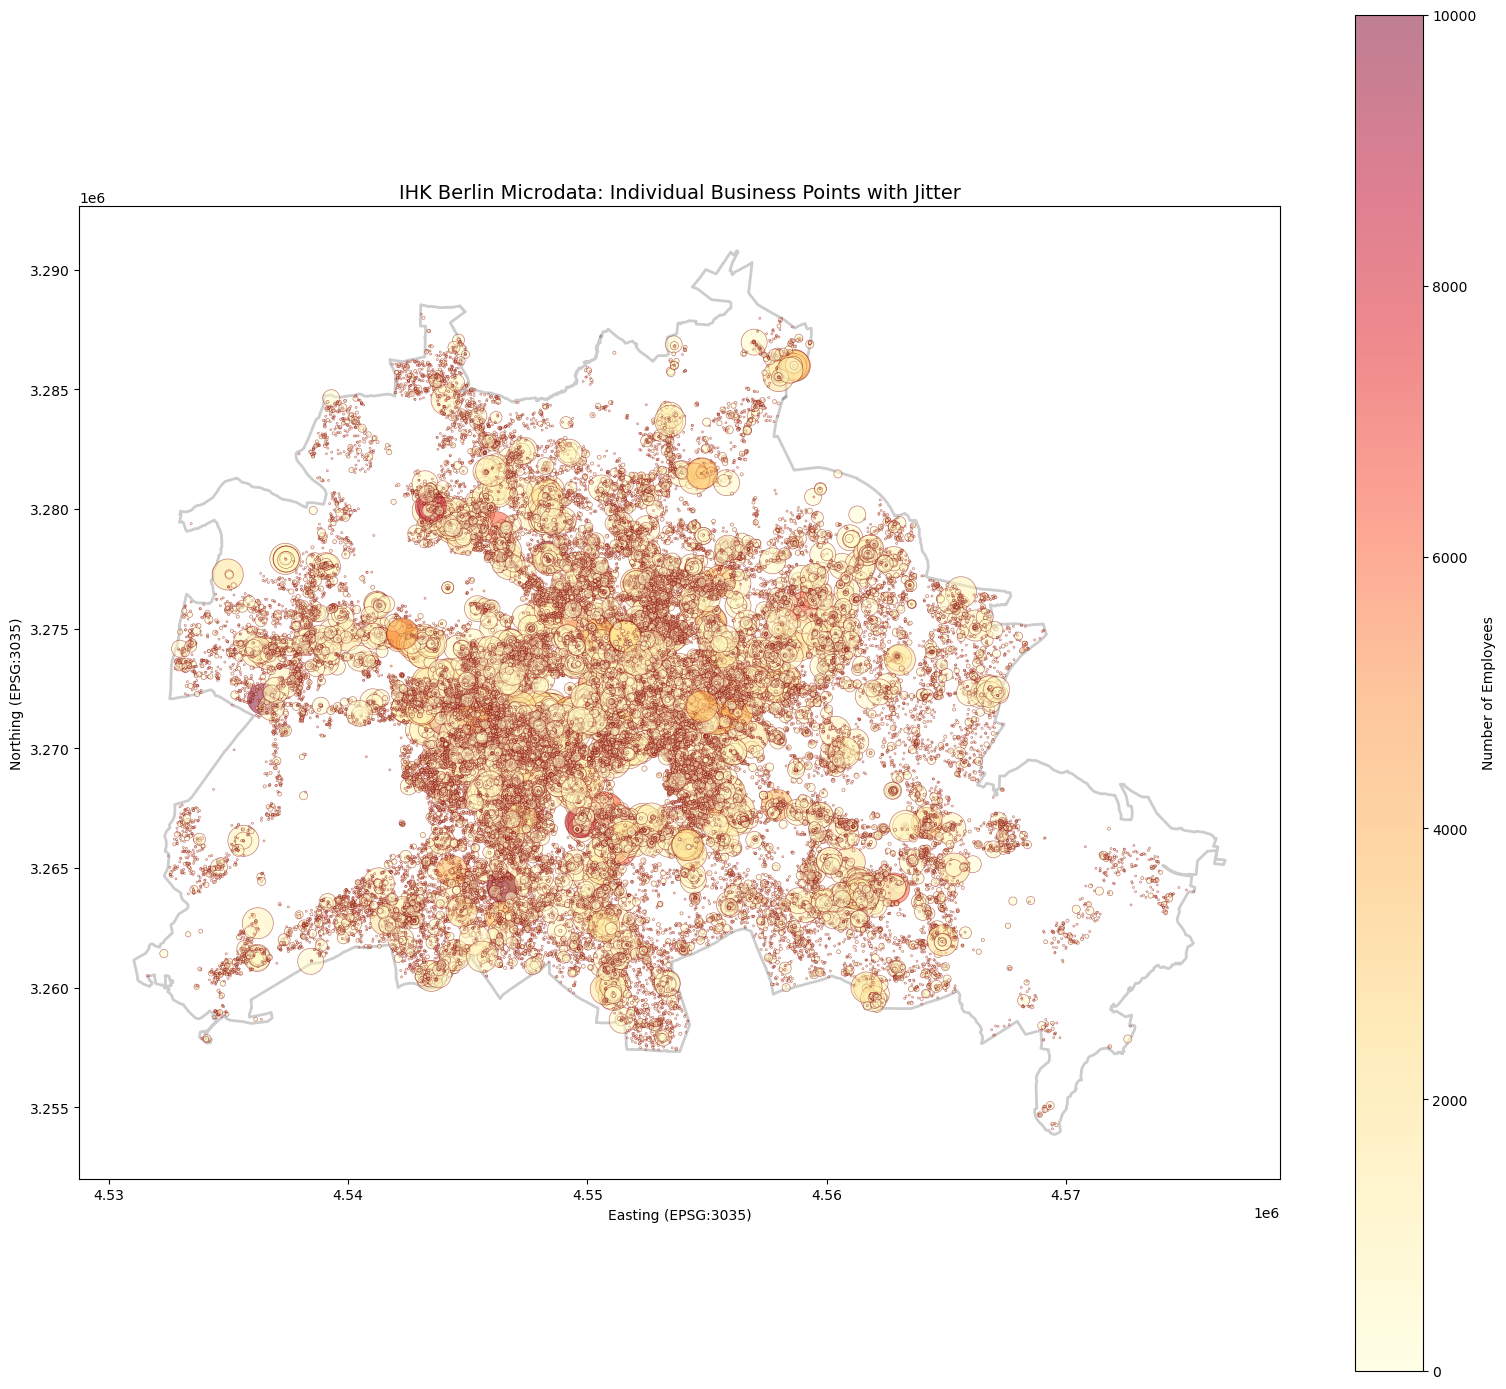

In [23]:
# === OPTION 3: Transparency + Jitter (reveals overlapping points) ===
# For static visualization: add small random spatial noise and use transparency
import matplotlib.pyplot as plt
from shapely.affinity import translate as translate_geom

# Create jittered copy using vectorized offset approach
np.random.seed(42)
jitter_scale = 20
jitter_x = np.random.normal(0, jitter_scale, len(IHK_gdf))
jitter_y = np.random.normal(0, jitter_scale, len(IHK_gdf))

# Apply jitter to geometries
IHK_jittered = IHK_gdf.copy()
IHK_jittered['geometry'] = [translate_geom(geom, xoff=dx, yoff=dy) 
                             for geom, dx, dy in zip(IHK_jittered.geometry, jitter_x, jitter_y)]

fig, ax = plt.subplots(figsize=(16, 14))
berlin.plot(ax=ax, alpha=0.2, edgecolor='black', facecolor='none', linewidth=2)
grid.plot(ax=ax, column='empl', cmap='YlGn', alpha=0.3, legend=False, edgecolor='none')

# Main visualization: size and color by employment
scatter = ax.scatter(
    IHK_jittered.geometry.x,
    IHK_jittered.geometry.y,
    s=IHK_jittered['empl'].fillna(1).clip(upper=500),  # Cap size for outliers
    c=IHK_jittered['empl'],
    cmap='YlOrRd',
    alpha=0.5,  # Transparency reveals overlaps
    edgecolors='darkred',
    linewidth=0.5
)
cbar = plt.colorbar(scatter, ax=ax, label='Number of Employees')
ax.set_title('IHK Berlin Microdata: Individual Business Points with Jitter', fontsize=14)
ax.set_xlabel('Easting (EPSG:3035)')
ax.set_ylabel('Northing (EPSG:3035)')
plt.tight_layout()
plt.show()

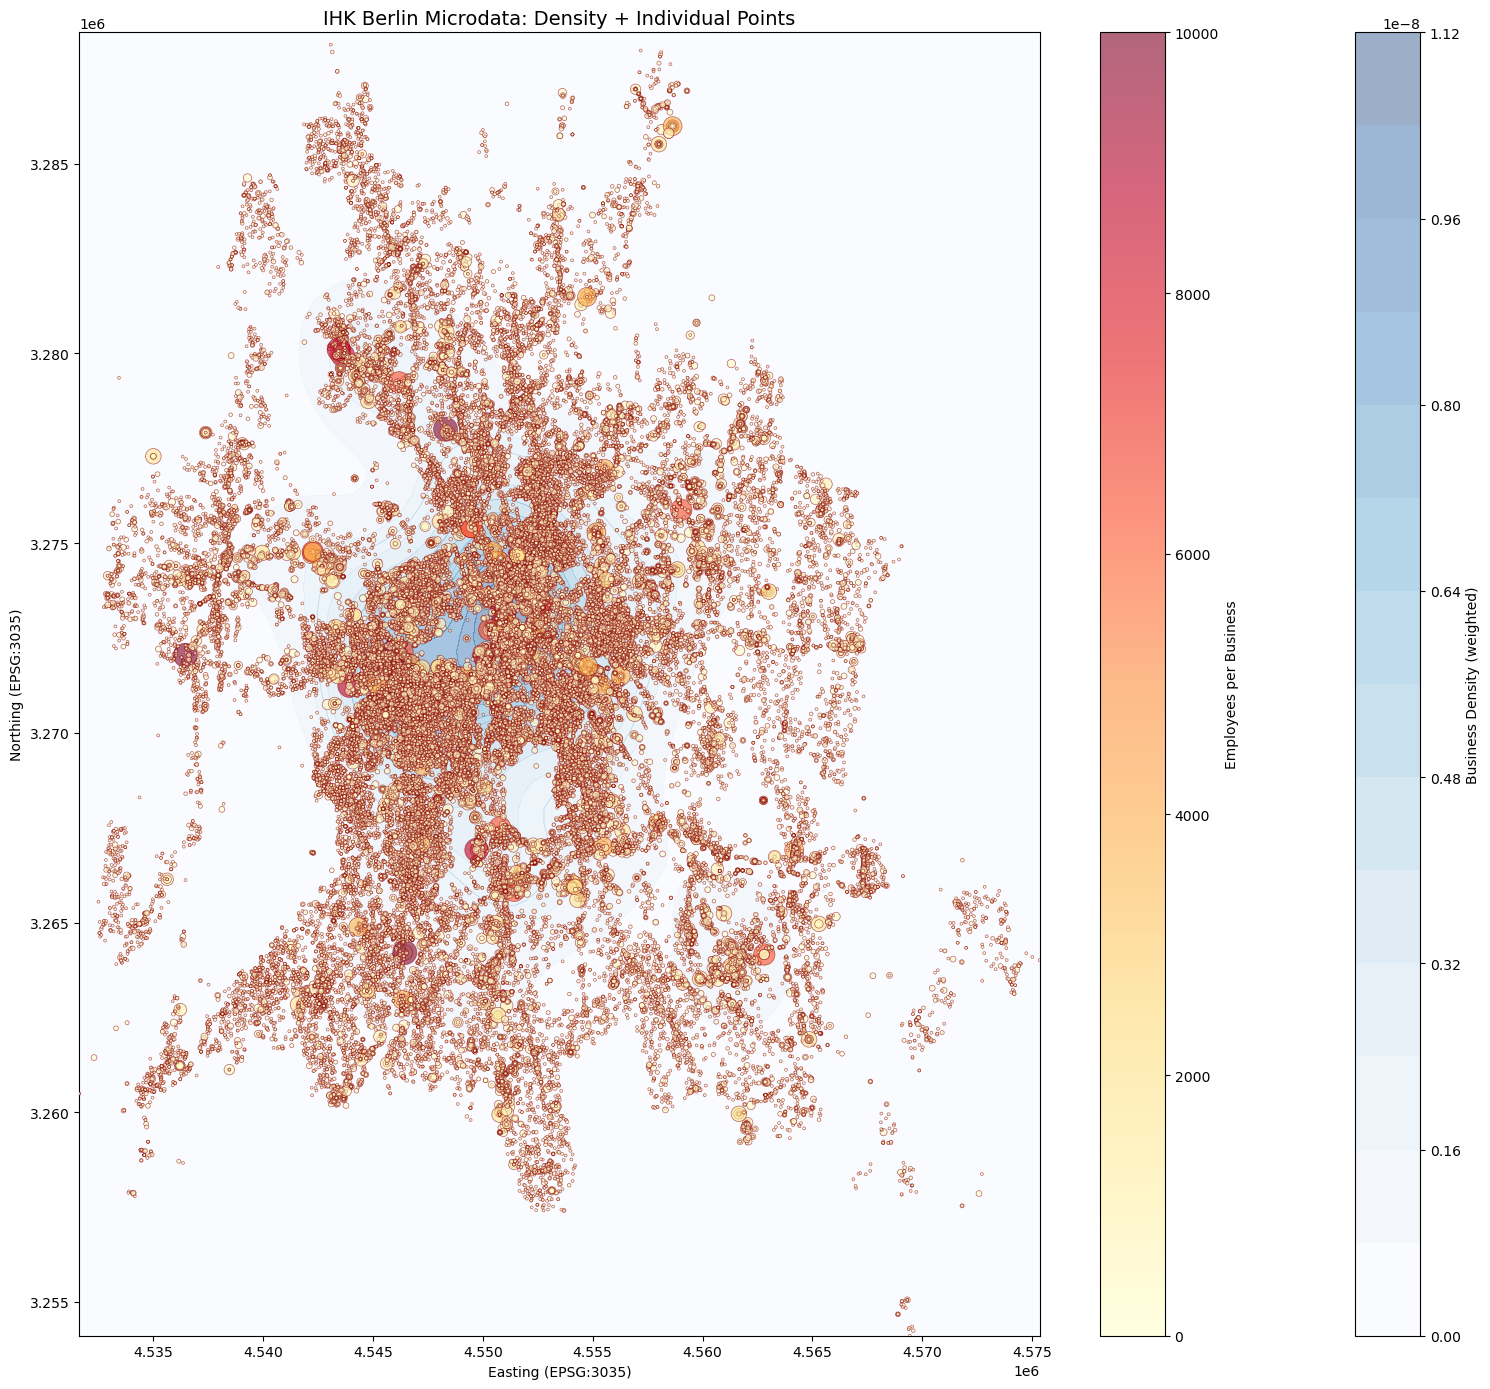

In [24]:
# === OPTION 4: Contour density + individual points ===
# Show both density patterns and individual locations
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(16, 14))

# Background: density heatmap
points = np.column_stack([IHK_gdf.geometry.x, IHK_gdf.geometry.y])
if len(points) > 1:
    kde = gaussian_kde(points.T, weights=IHK_gdf['empl'].fillna(1))
    
    # Create grid for KDE evaluation
    x_min, x_max = IHK_gdf.geometry.x.min(), IHK_gdf.geometry.x.max()
    y_min, y_max = IHK_gdf.geometry.y.min(), IHK_gdf.geometry.y.max()
    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    z = kde(positions).reshape(xx.shape)
    
    # Plot contours of density
    contourf = ax.contourf(xx, yy, z, levels=15, cmap='Blues', alpha=0.4)
    contour = ax.contour(xx, yy, z, levels=5, colors='steelblue', alpha=0.3, linewidths=0.5)
    plt.colorbar(contourf, ax=ax, label='Business Density (weighted)')

# Overlay individual points
scatter = ax.scatter(
    IHK_gdf.geometry.x,
    IHK_gdf.geometry.y,
    s=np.sqrt(IHK_gdf['empl'].fillna(1)) * 3,
    c=IHK_gdf['empl'],
    cmap='YlOrRd',
    alpha=0.6,
    edgecolors='darkred',
    linewidth=0.5,
    zorder=5
)
plt.colorbar(scatter, ax=ax, label='Employees per Business')
ax.set_title('IHK Berlin Microdata: Density + Individual Points', fontsize=14)
ax.set_xlabel('Easting (EPSG:3035)')
ax.set_ylabel('Northing (EPSG:3035)')
plt.tight_layout()
plt.show()